## Эксперимент 2. Модели с временными/лаговыми признаками

### Скачиваем данные

In [20]:
import pandas as pd
import numpy as np

model_data = pd.read_parquet("model_data_extended_2.parquet")

print(model_data.shape)
model_data.head()

(1000000, 36)


,secret_id,rn,created_dt,max_turnover,max_turnover_clipped,log_target,log_income,finalincome,all_bki_current_pmt,all_tinkoff_current_pmt,...,income_x_transaction_is_null,annual_revenue_is_null,vital_business_flg_is_null,risk_flg,phoenix_reject_flg,fns_status_problems_flg,vital_business_flg,okved_cluster,log_income_bucket,company_age_bucket
0,898a8b57faca0feb7e0ee11de6245af1,1,2026-04-28,1051666.67,1051666.67,13.87,13.33,617213,71477.01,70040.00,...,1,1,0,0,0,0,0.00,1,"(13.294, 20.724]",13-36
1,6c2f92f34b1ee3858a18421ebcede90b,3,2026-02-27,4267416.67,4267416.67,15.27,11.57,106136,37087.40,13800.00,...,1,0,0,0,0,0,0.00,2,"(11.488, 11.668]",85-180
2,ce0d5b0651e61d30282c260093893e7f,5,2025-08-16,902416.67,902416.67,13.71,11.63,112500,0.00,0.00,...,1,0,1,0,0,0,NaN,2,"(11.488, 11.668]",180+
3,a8e7c44015a356cc7bea31abcf759225,3,2025-12-30,50000.00,50000.00,10.82,13.00,441166,5546.72,42180.00,...,1,1,0,0,0,0,0.00,1,"(12.785, 13.294]",180+
4,3b43cc8fd5fe16200a62a84916a0ebd4,4,2026-03-07,2363054.05,2363054.05,14.68,12.03,168490,45451.90,0.00,...,0,1,0,0,0,0,0.00,2,"(11.949, 12.127]",85-180


### Подготовка данных и базовые проверки корректности

In [21]:
pd.set_option('display.float_format', '{:.2f}'.format)
model_data.dtypes

,0
secret_id,object
rn,int64
created_dt,object
max_turnover,float64
max_turnover_clipped,float64
log_target,float64
log_income,float64
finalincome,int64
all_bki_current_pmt,float64
all_tinkoff_current_pmt,float64


In [3]:
model_data.isnull().mean().sort_values(ascending=False)

,0
pred_transaction_amt,0.76
business_signal,0.76
transaction_amt,0.76
transactions_to_income,0.76
transaction_cnt,0.76
vital_business_flg,0.18
all_tinkoff_current_pmt,0.00
all_bki_current_pmt,0.00
company_age,0.00
secret_id,0.00


Визуализации для анализа результатов:

1. Сравнение предсказаний и реальных значений (scatterplot)

In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model", alpha=0.05):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=alpha)

    min_val = min(np.min(y_true), np.min(y_pred))

    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual log_target")
    plt.ylabel("Predicted log_target")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()


2. Сравнение распределений метрики  𝑦̂  и y.

In [79]:
def plot_prediction_distribution(y_true, y_pred, model_name="Model", bins=100):
    plt.figure(figsize=(12, 6))

    plt.hist(y_true, bins=bins, alpha=0.5, label="Actual")

    plt.hist(y_pred, bins=bins, alpha=0.5, label="Predicted")

    plt.xlabel("log_target")
    plt.ylabel("Count")

    plt.title(f"{model_name}: Prediction Distribution")

    plt.legend()
    plt.show()

3. Сравнение распределений метрики  𝑦̂  и y при  𝑦̂  > treshold

In [80]:
def plot_nonzero_distribution(y_true, y_pred=None, model_name="Model", bins=100, min_turnover=1000):
    threshold = np.log1p(min_turnover)
    true_mask = y_true > threshold
    plt.figure(figsize=(12, 6))

    # actual distribution
    plt.hist(y_true[true_mask], bins=bins, alpha=0.5, label="Actual non-zero")

    # predicted distribution
    if y_pred is not None:
        pred_mask = y_pred > threshold
        plt.hist(y_pred[pred_mask], bins=bins, alpha=0.5, label="Predicted non-zero")

    plt.xlabel("log_target")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Non-zero Turnover Distribution")

    plt.legend()
    plt.show()

4. Сравнение распределений остатков  𝑦−𝑦̂

In [81]:
def plot_residual_distribution(y_true, y_pred, model_name="Model", bins=100):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 6))
    plt.hist(residuals, bins=bins)

    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")

    plt.show()

Формируем выборку. Добавляем обрезку таргета сверху для сглаживания слишком высоких оборотов - выбросов.

In [22]:
target_raw = "max_turnover"
target = "log_target"
clip_q = 0.995

upper_target = model_data[target_raw].quantile(clip_q)

model_data["max_turnover_clipped"] = model_data[target_raw].clip(
    upper=upper_target
)

model_data["log_transaction_amt"] = np.where(
    model_data["transaction_amt"].notna(),
    np.log1p(model_data["transaction_amt"]),
    np.nan
)

model_data["log_pred_transaction_amt"] = np.where(
    model_data["pred_transaction_amt"].notna(),
    np.log1p(model_data["pred_transaction_amt"]),
    np.nan
)

model_data["log_all_tinkoff_current_pmt"] = np.where(
    model_data["all_tinkoff_current_pmt"].notna(),
    np.log1p(model_data["all_tinkoff_current_pmt"]),
    np.nan
)

model_data["log_all_bki_current_pmt"] = np.where(
    model_data["all_bki_current_pmt"].notna(),
    np.log1p(model_data["all_bki_current_pmt"]),
    np.nan
)

Вводим список признаков, которые изменяются с течением времени. Это данные о количестве/сумме транзакций, доходе, платежах по кредитам и тд.

In [23]:
dynamic_cols = [
    "transaction_cnt",
    "log_transaction_amt",
    "log_pred_transaction_amt",
    "log_income",

    "log_all_bki_current_pmt",
    "log_all_tinkoff_current_pmt",

    "payment_to_income",
    "payment_bki_to_income",
    "payment_tkf_to_income"
]

In [24]:
growth_cols = [
    "transaction_cnt",
    "log_transaction_amt",
    "log_pred_transaction_amt",
    "log_income",
    "log_all_bki_current_pmt",
    "log_all_tinkoff_current_pmt"
]

Для динамических признаков мы будем находить:
1) lag - значение в предыдущее временное значение
2) rolling_avg - усредненное значение всех предыдущих результатов
3) growth = $\frac{x_t - x_{t-1}}{x_{t-1}}$. Показывает, насколько быстро меняется показатель.
4) delta = $x_t - x_{t-1}$. Показывает, как изменяется показатель в абсолютной шкале.

При этом, последние 2 признака будем находить только для признаков, не являющихся относительными (payment_to_income - коэффициент, и показатель его относительного/абсолютного роста не даст значимой информации для модели).

Функции для формирования признаков, описанных выше.

1) Функция для формирования датасета, отсортированного по айди клиента и номеру его скоринга

In [25]:
def prepare_temporal_base(
    data,
    group_col="secret_id",
    order_col="rn"
):
    return (
        data
        .sort_values([group_col, order_col])
        .reset_index(drop=True)
        .copy()
    )

2. Функция для добавления значений предыдущего (в том числе и с шагом 2) скоринга.

In [26]:
def add_lag_features(
    temporal_data,
    dynamic_cols,
    group_col="secret_id",
    lags=(1, 2)
):
    grouped = temporal_data.groupby(group_col, sort=False)

    new_parts = []

    for lag in lags:
        lagged = grouped[dynamic_cols].shift(lag)
        lagged.columns = [
            f"{col}_lag_{lag}"
            for col in dynamic_cols
        ]
        new_parts.append(lagged)

    return pd.concat([temporal_data] + new_parts, axis=1)

3. Функция для определения скользящего среднего по скорингам внутри заданного окна (параметр windows)

In [27]:
def add_rolling_features(
    temporal_data,
    dynamic_cols,
    group_col="secret_id",
    windows=(2, 3),
    add_std=True
):
    grouped = temporal_data.groupby(group_col, sort=False)

    shifted = grouped[dynamic_cols].shift(1)

    new_parts = []

    for window in windows:
        roll_mean = (
            shifted
            .groupby(temporal_data[group_col], sort=False)
            .rolling(window=window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        roll_mean.columns = [
            f"{col}_roll_mean_{window}"
            for col in dynamic_cols
        ]

        new_parts.append(roll_mean)

        if add_std:
            roll_std = (
                shifted
                .groupby(temporal_data[group_col], sort=False)
                .rolling(window=window, min_periods=2)
                .std()
                .reset_index(level=0, drop=True)
            )

            roll_std.columns = [
                f"{col}_roll_std_{window}"
                for col in dynamic_cols
            ]

            new_parts.append(roll_std)

    return pd.concat([temporal_data] + new_parts, axis=1)

4. Функция для определения относительного изменения метрики

In [28]:
def add_delta_growth_features(
    temporal_data,
    growth_cols,
    eps=1
):
    new_parts = []

    for col in growth_cols:
        lag_col = f"{col}_lag_1"

        if lag_col not in temporal_data.columns:
            continue

        delta = (
            temporal_data[col]
            - temporal_data[lag_col]
        )

        growth = (
            delta
            / (temporal_data[lag_col].abs() + eps)
        )

        new_parts.append(
            pd.DataFrame({
                f"{col}_delta_1": delta,
                f"{col}_growth_1": growth
            })
        )

    return pd.concat([temporal_data] + new_parts, axis=1)

5. Функция для определения количества прошедших с предыдущего скоринга дней

In [34]:
def add_days_since_prev_score(
    temporal_data,
    group_col="secret_id",
    date_col="created_dt"
):
    temporal_data = temporal_data.copy()

    temporal_data[date_col] = pd.to_datetime(
        temporal_data[date_col]
    )

    temporal_data["prev_score_dt"] = (
        temporal_data
        .groupby(group_col, sort=False)[date_col]
        .shift(1)
    )

    temporal_data["days_since_prev_score"] = (
        temporal_data[date_col]
        - temporal_data["prev_score_dt"]
    ).dt.days

    temporal_data["has_prev_score_dt"] = (
        temporal_data["prev_score_dt"].notna()
    ).astype(int)

    temporal_data = temporal_data.drop(
        columns=["prev_score_dt"]
    )

    return temporal_data

In [35]:
def add_history_depth_features(
    temporal_data,
    group_col="secret_id"
):
    temporal_data = temporal_data.copy()

    grouped = temporal_data.groupby(group_col, sort=False)

    temporal_data["score_number_for_client"] = (
        grouped.cumcount() + 1
    )

    temporal_data["has_previous_score"] = (
        temporal_data["score_number_for_client"] > 1
    ).astype(int)

    temporal_data["has_2_previous_scores"] = (
        temporal_data["score_number_for_client"] > 2
    ).astype(int)

    return temporal_data

Генерируем значения временных признаков по клиентам

Добавляем дополнительные признаки, означающие наличие историчности у клиента. Гипотеза: такие признаки помогут скалибровать веса у временных признаков.

In [38]:
# temporal_model_data = prepare_temporal_base(
#     model_data,
#     group_col="secret_id",
#     order_col="rn"
# )

temporal_model_data = (
    model_data
    .sort_values(["secret_id", "rn"], ascending=[True, False])
    .reset_index(drop=True)
    .copy()
)

temporal_model_data = add_lag_features(
    temporal_model_data,
    dynamic_cols=dynamic_cols,
    group_col="secret_id",
    lags=(1, 2)
)

temporal_model_data = add_rolling_features(
    temporal_model_data,
    dynamic_cols=dynamic_cols,
    group_col="secret_id",
    windows=(2, 3),
    add_std=False
)

temporal_model_data = add_delta_growth_features(
    temporal_model_data,
    growth_cols=growth_cols,
    eps=1
)

temporal_model_data = add_history_depth_features(
    temporal_model_data,
    group_col="secret_id"
)

temporal_model_data = add_days_since_prev_score(
    temporal_model_data,
    group_col="secret_id",
    date_col="created_dt"
)

Проверяем созданные значения

In [39]:
check_cols = [
    "secret_id",
    "rn",
    "created_dt",
    "score_number_for_client",
    "has_previous_score",
    "days_since_prev_score",
    "has_prev_score_dt",

    "transaction_cnt",
    "transaction_cnt_lag_1",
    "transaction_cnt_lag_2",
    "transaction_cnt_roll_mean_2",
    "transaction_cnt_roll_mean_3",
    "transaction_cnt_delta_1",
    "transaction_cnt_growth_1"
]

temporal_model_data[check_cols].head(30)

,secret_id,rn,created_dt,score_number_for_client,has_previous_score,days_since_prev_score,has_prev_score_dt,transaction_cnt,transaction_cnt_lag_1,transaction_cnt_lag_2,transaction_cnt_roll_mean_2,transaction_cnt_roll_mean_3,transaction_cnt_delta_1,transaction_cnt_growth_1
0,00000392ef72ab030b59cbfc1ec8fdfa,5,2025-12-08,1,0,NaN,0,478.00,NaN,NaN,NaN,NaN,NaN,NaN
1,00000392ef72ab030b59cbfc1ec8fdfa,4,2025-12-21,2,1,13.00,1,411.00,478.00,NaN,478.00,478.00,-67.00,-0.14
2,00000392ef72ab030b59cbfc1ec8fdfa,3,2026-01-22,3,1,32.00,1,331.00,411.00,478.00,444.50,444.50,-80.00,-0.19
3,00000392ef72ab030b59cbfc1ec8fdfa,2,2026-02-23,4,1,32.00,1,288.00,331.00,411.00,371.00,406.67,-43.00,-0.13
4,00000392ef72ab030b59cbfc1ec8fdfa,1,2026-05-02,5,1,68.00,1,307.00,288.00,331.00,309.50,343.33,19.00,0.07
5,0000244510c1b95c13235626b3e9a936,5,2026-03-02,1,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0000244510c1b95c13235626b3e9a936,4,2026-03-14,2,1,12.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0000244510c1b95c13235626b3e9a936,3,2026-03-15,3,1,1.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0000244510c1b95c13235626b3e9a936,2,2026-03-17,4,1,2.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0000244510c1b95c13235626b3e9a936,1,2026-04-16,5,1,30.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Временные признаки:

In [40]:
temporal_feature_cols = []

for col in dynamic_cols:
    temporal_feature_cols += [
        f"{col}_lag_1",
        f"{col}_lag_2",
        f"{col}_roll_mean_2",
        f"{col}_roll_mean_3",
    ]

for col in growth_cols:
    temporal_feature_cols += [
        f"{col}_delta_1",
        f"{col}_growth_1"
    ]

history_features = [
    "score_number_for_client",
    "has_previous_score",
    "has_2_previous_scores",
    "days_since_prev_score",
    "has_prev_score_dt"
]

temporal_feature_cols = list(dict.fromkeys(
    temporal_feature_cols + history_features
))

Базовые признаки:

In [41]:
base_features = [
    "log_income",

    "all_bki_current_pmt",
    "all_tinkoff_current_pmt",
    "log_all_bki_current_pmt",
    "log_all_tinkoff_current_pmt",

    "payment_to_income",
    "payment_bki_to_income",
    "payment_tkf_to_income",

    "transaction_amt",
    "transaction_cnt",
    "pred_transaction_amt",

    "log_transaction_amt",
    "log_pred_transaction_amt",

    "avg_transaction",
    "business_signal",
    "transactions_to_income",

    "company_age",

    "ip_flg",

    "transaction_amt_is_null",
    "transaction_cnt_is_null",
    "pred_transaction_amt_is_null",

    "business_signal_is_null",
    "transactions_to_income_is_null",

    "risk_flg",
    "phoenix_reject_flg",
    "fns_status_problems_flg",

    "vital_business_flg",

    "okved_cluster"
]

Объединяем пул признаков и формируем общий датасет

In [42]:
temporal_boosting_features = (
    base_features
    + temporal_feature_cols
)

temporal_boosting_features = list(dict.fromkeys(
    temporal_boosting_features
))

In [43]:
X = temporal_model_data[
    temporal_boosting_features
].copy()

y = temporal_model_data["log_target"].copy()

groups = temporal_model_data["secret_id"]

В качестве модели будем использовать лучший результат эксперимента 1 - градиентный бустинг CatBoost.

Готовим список категориальных признаков (он будет обрабатываться отдельно) и заполняем Null-ы

In [44]:
cat_features = [
    "ip_flg",

    "transaction_amt_is_null",
    "transaction_cnt_is_null",
    "pred_transaction_amt_is_null",

    "business_signal_is_null",
    "transactions_to_income_is_null",

    "risk_flg",
    "phoenix_reject_flg",
    "fns_status_problems_flg",

    "vital_business_flg",

    "okved_cluster",

    "has_previous_score",
    "has_2_previous_scores",

    "has_prev_score_dt"
]

In [45]:
for col in cat_features:
    X[col] = (
        X[col]
        .fillna("missing")
        .astype(str)
    )

Сплит на тест/треин с условием на то, что каждый клиент может быть только в одной выборке

In [46]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

In [47]:
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = (
    temporal_model_data
    .iloc[train_idx]["secret_id"]
    .reset_index(drop=True)
)

Добавляем сплит обучающей выборки для валидации

In [48]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)

inner_train_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=train_groups
    )
)

In [50]:
X_inner_train = (X_train.iloc[inner_train_idx].copy())

y_inner_train = (y_train.iloc[inner_train_idx].copy())

X_val = (X_train.iloc[val_idx].copy())

y_val = (y_train.iloc[val_idx].copy())

Преобразуем датасеты в формат CatBoostPool для удобства

In [52]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.5 MB/s eta 0:00:00


In [54]:
from catboost import CatBoostRegressor, Pool

train_pool = Pool(
    X_inner_train,
    y_inner_train,
    cat_features=cat_features
)

val_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_features
)

Обучаем модель, добавляя механизм early stopping с защитой от переобучения.

In [58]:
temporal_catboost = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,

    loss_function="RMSE",
    eval_metric="RMSE",

    early_stopping_rounds=200,

    random_seed=42,
    verbose=100
)

In [59]:
temporal_catboost.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

0:	learn: 6.5783962	test: 6.5786982	best: 6.5786982 (0)	total: 725ms	remaining: 24m 9s
100:	learn: 5.4393887	test: 5.4636157	best: 5.4636157 (100)	total: 1m 21s	remaining: 25m 27s
200:	learn: 5.4011389	test: 5.4296061	best: 5.4296061 (200)	total: 2m 37s	remaining: 23m 28s
300:	learn: 5.3847681	test: 5.4179339	best: 5.4179339 (300)	total: 3m 53s	remaining: 21m 58s
400:	learn: 5.3733845	test: 5.4108250	best: 5.4108250 (400)	total: 5m 10s	remaining: 20m 38s
500:	learn: 5.3617014	test: 5.4042506	best: 5.4042506 (500)	total: 6m 29s	remaining: 19m 25s
600:	learn: 5.3514666	test: 5.3995149	best: 5.3995149 (600)	total: 7m 47s	remaining: 18m 8s
700:	learn: 5.3425979	test: 5.3969027	best: 5.3969027 (700)	total: 9m 5s	remaining: 16m 50s
800:	learn: 5.3343375	test: 5.3950835	best: 5.3950800 (799)	total: 10m 25s	remaining: 15m 35s
900:	learn: 5.3269302	test: 5.3938939	best: 5.3938936 (898)	total: 11m 41s	remaining: 14m 15s
1000:	learn: 5.3198806	test: 5.3927449	best: 5.3927449 (1000)	total: 12m 58s

CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [60]:
history = temporal_catboost.get_evals_result()
history.keys()

dict_keys(['learn', 'validation'])

Кривые обучения:

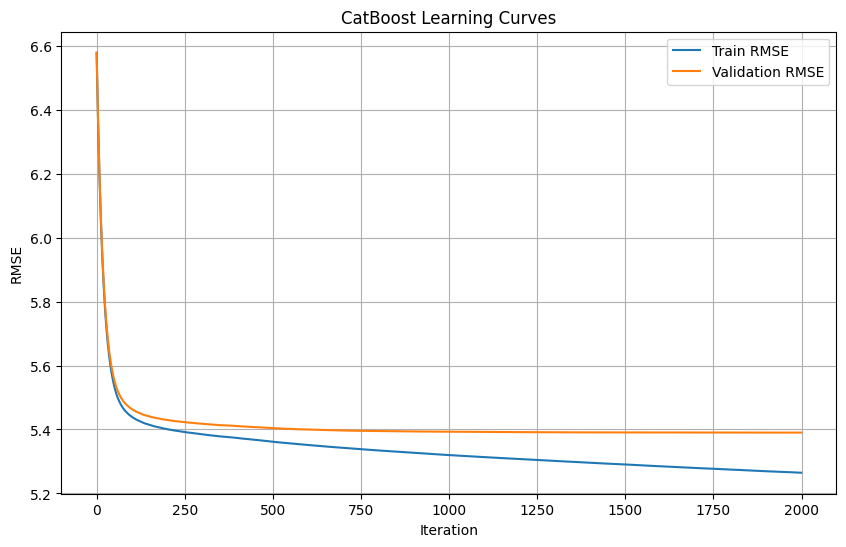

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history["learn"]["RMSE"],
    label="Train RMSE"
)

plt.plot(
    history["validation"]["RMSE"],
    label="Validation RMSE"
)

plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curves")

plt.legend()

plt.grid(True)

plt.show()

По графику видно, что после ~1250 итераций кривая валидации выходит на плато, однако не начинает возрастать, что свидетельствует о том, что модель не переобучается. Early Stopping указывает на оптимальное число итераций = 1998, оставим веса с этого значения в качестве оптимальных

Получаем предсказания на тестовой выборке:

In [64]:
test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

In [66]:
y_pred_log_raw = temporal_catboost.predict(
    test_pool
)

upper_pred_log = (
    temporal_model_data["log_target"]
    .quantile(0.999)
)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

Возвращаем в исходный мастштаб и считаем метрики:

In [67]:
y_true_log = y_test.values
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

over_15 = (y_pred > 1.5 * np.maximum(y_true, 1)).mean()
under_15 = (y_pred < y_true / 1.5).mean()

In [77]:
print(f"Метрики в лог-шкале:\n\nMAE log:  {mae_log:.4f}\nRMSE log: {rmse_log:.4f}\nR2 log:   {r2_log:.4f}")

print(f"\nМетрики в оригинальной шкале:\n\nMAE:  {mae:,.2f}\nRMSE: {rmse:,.2f}")

print("\nБизнес-метрики:\n")

print(f"Переоценка оборота > 1.5x:  {over_15:.2%}")
print(f"Недооценка оборота > 1.5x: {under_15:.2%}")

Метрики в лог-шкале:

MAE log:  4.5083
RMSE log: 5.3850
R2 log:   0.3418

Метрики в оригинальной шкале:

MAE:  1,739,091.40
RMSE: 7,796,200.74

Бизнес-метрики:

Переоценка оборота > 1.5x:  43.72%
Недооценка оборота > 1.5x: 45.84%


Визуализации распределений:

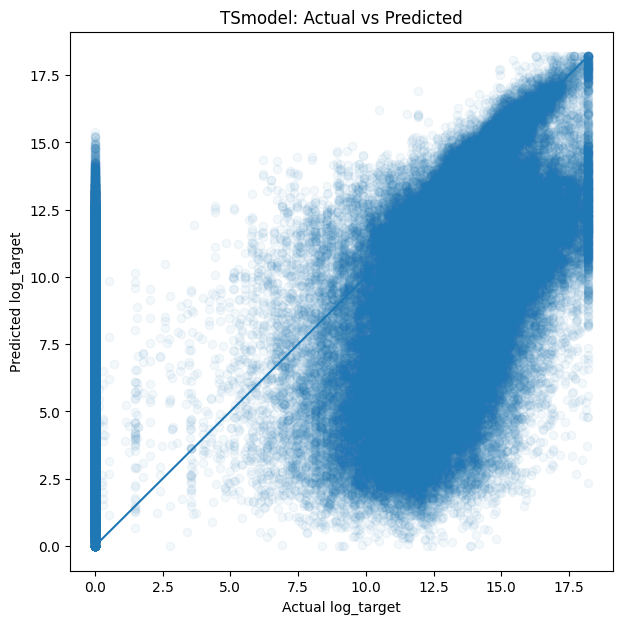

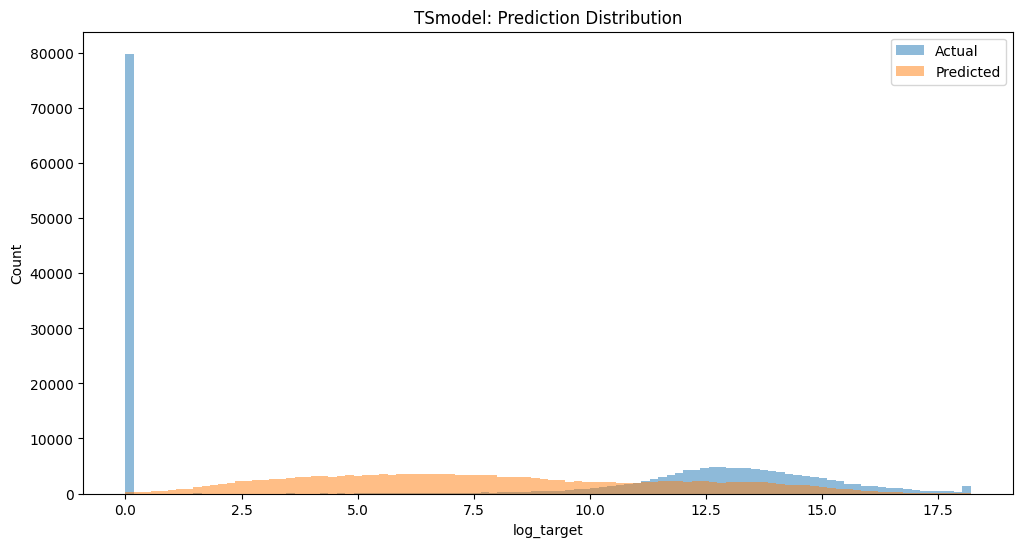

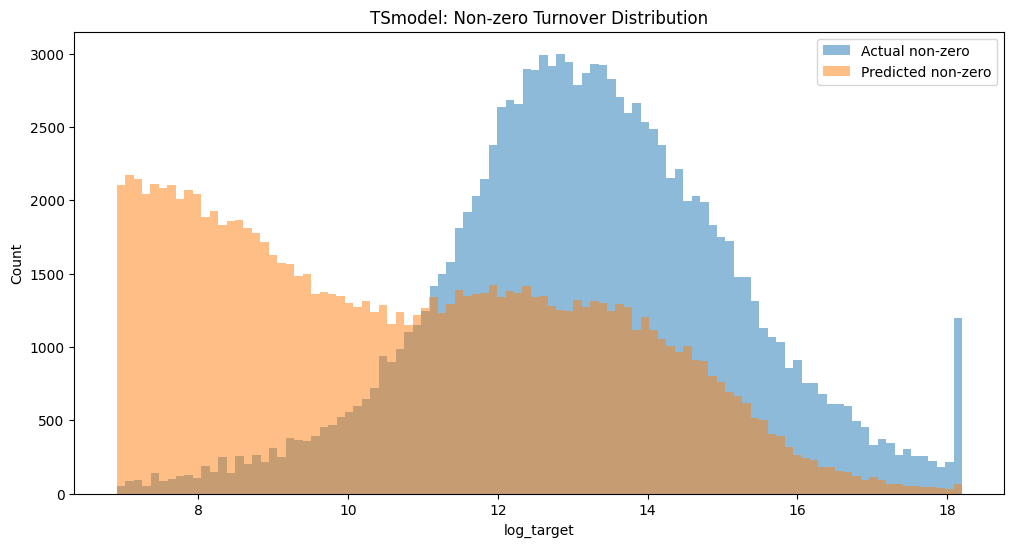

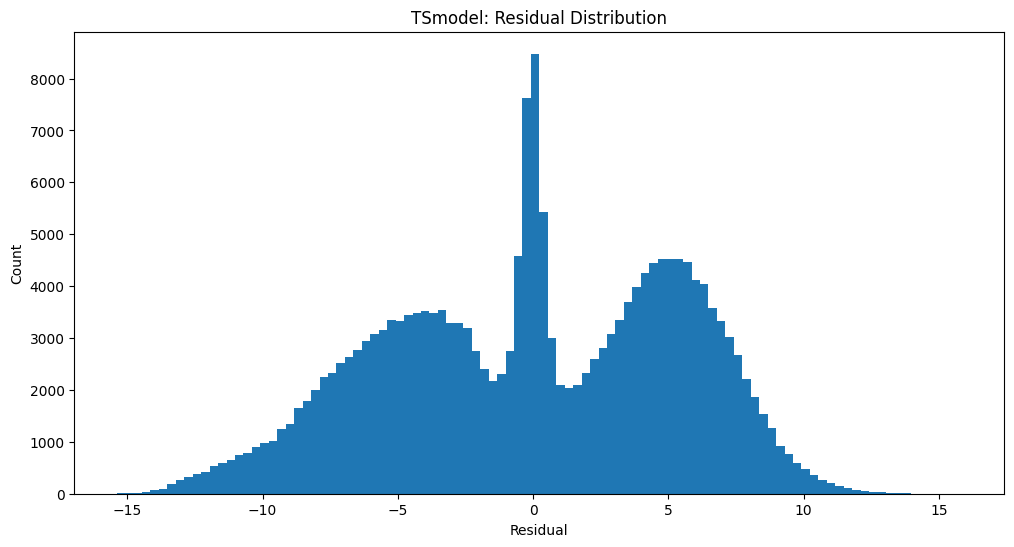

In [82]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="TSmodel"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="TSmodel"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="TSmodel",
    min_turnover=1000
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="TSmodel"
)


Важность признаков для модели:

In [84]:
feature_importance = pd.DataFrame({
    "feature": temporal_boosting_features,
    "importance": temporal_catboost.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
17,ip_flg,33.74
9,transaction_cnt,25.21
0,log_income,9.31
16,company_age,5.99
79,days_since_prev_score,3.61
27,okved_cluster,2.05
6,payment_bki_to_income,1.58
26,vital_business_flg,1.02
71,log_income_growth_1,0.94
5,payment_to_income,0.91


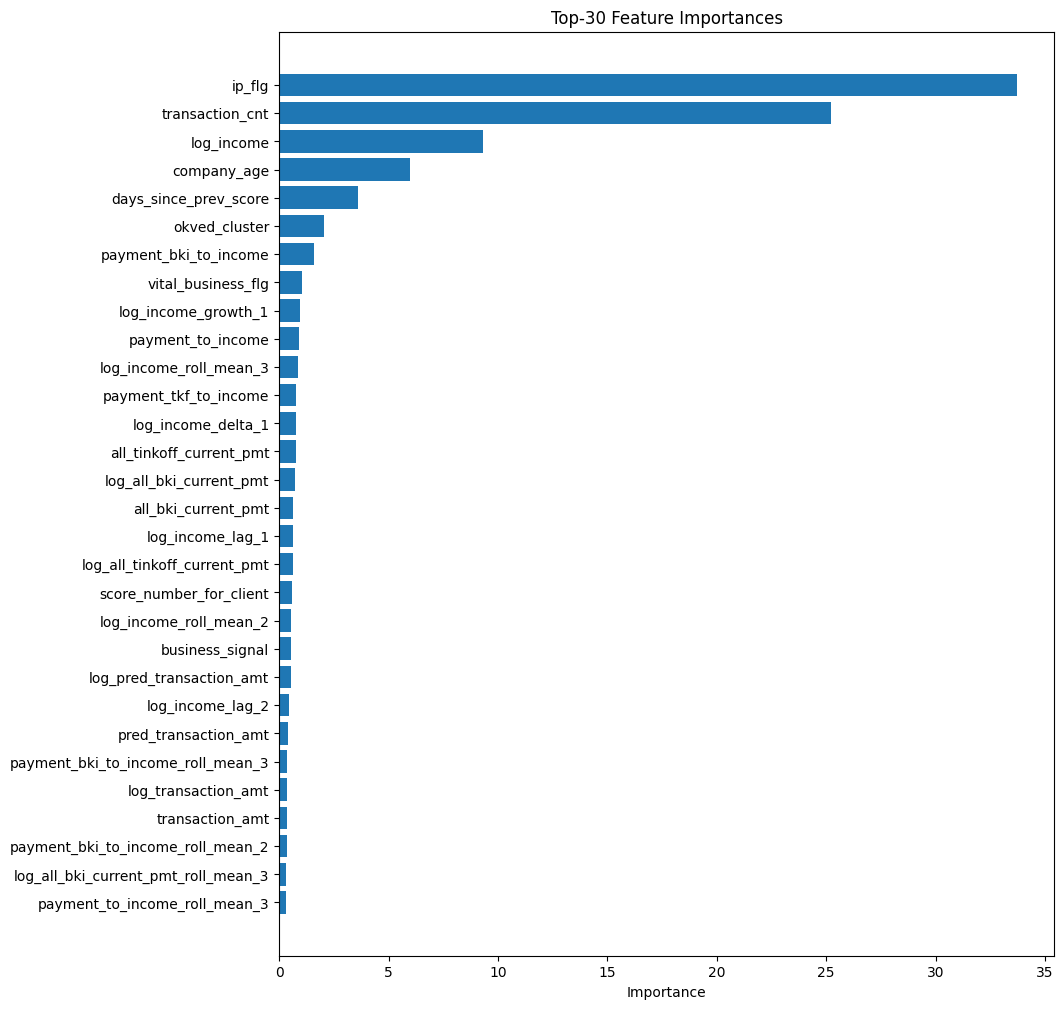

In [85]:
top_n = 30

top_features = (
    feature_importance
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(10, 12))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(f"Top-{top_n} Feature Importances")

plt.xlabel("Importance")

plt.show()

Отдельный разрез влияния статических и динамических признаков:

In [86]:
feature_importance["is_temporal"] = (
    feature_importance["feature"]
    .str.contains(
        "lag_|roll_|growth_|delta_|score_number|days_since",
        regex=True
    )
)

In [87]:
temporal_importance = (
    feature_importance
    .loc[
        feature_importance["is_temporal"],
        "importance"
    ]
    .sum()
)

static_importance = (
    feature_importance
    .loc[
        ~feature_importance["is_temporal"],
        "importance"
    ]
    .sum()
)

print(f"Temporal importance: {temporal_importance:.2f}")
print(f"Static importance:   {static_importance:.2f}")

Temporal importance: 13.81
Static importance:   86.19


Выводы:

1. Добавление временных признаков улучшило качество модели по сравнению со static CatBoost:

* R² в лог-шкале вырос с 0.3282 до 0.3418;
* снизились MAE log и RMSE log.

2. История скорингов клиента действительно содержит дополнительный predictive signal:

* модель использует не только текущее состояние клиента, но и динамику изменения финансовой активности.

3. Business-метрики изменились незначительно:

* temporal features улучшают общее качество аппроксимации,
* но пока не приводят к существенному снижению крупных ошибок прогноза (>1.5x).

4. В самые важные признаки добавились days_since_prev_score (дни с предыдущего скоринга) и log_income_growth_1 (относительный прирост дохода клиента)

5. Влияние динамических признаков на результат составляет до 14%, что является важным улучшением модели

Скачиваем веса и фичи модели для дальнейших экспериментов:

In [89]:
temporal_catboost.save_model(
    "temporal_catboost.cbm"
)

In [88]:
import json

with open(
    "temporal_boosting_features.json",
    "w"
) as f:
    json.dump(
        temporal_boosting_features,
        f
    )